# Libraries

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 915.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.1 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import json
import importlib.util
import torch



In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!git clone -b feature/cv-yolo-detection https://github.com/Govind-2004/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization.git

Cloning into 'AI_Adaptive_Traffic_Analysis_and_Signal_Optimization'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 228 (delta 37), reused 26 (delta 26), pack-reused 188 (from 1)
Receiving objects: 100% (228/228), 15.51 MiB | 14.68 MiB/s, done.
Resolving deltas: 100% (73/73), done.


In [5]:
%cd /content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization

/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization


# Load and generate track data

In [6]:
video_path = "/content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo/HnVideoEditor_2026_09_20_102852705.mp4"

print("Video exists:", os.path.exists(video_path))

Video exists: True


In [7]:
repo_path = "/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization"

tracker_path = f"{repo_path}/cv/tracking/tracker.py"
detector_path = f"{repo_path}/cv/detection/detector.py"

# Load detector.py
spec = importlib.util.spec_from_file_location("detector", detector_path)
detector = importlib.util.module_from_spec(spec)
spec.loader.exec_module(detector)

# Load tracker.py
spec = importlib.util.spec_from_file_location("tracker", tracker_path)
tracker = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tracker)

model, device = detector.load_model()

print("Device:", device)
print("Vehicle classes:", detector.VEHICLE_CLASSES)
print("Tracker module loaded:", hasattr(tracker, "track_vehicles"))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Device: cuda
Vehicle classes: {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}
Tracker module loaded: True


In [9]:
# Generating the tracking data
video_path = "/content/drive/MyDrive/Colab Notebooks/Datasets /Capstone_traffic/Demo/HnVideoEditor_2026_09_20_102852705.mp4"

tracking_rows = []

results = tracker.track_vehicles(
    video_path=video_path,
    model=model,
    classes=detector.VEHICLE_CLASSES,
    tracker="bytetrack.yaml",
    conf=0.35
)

for frame_idx, result in enumerate(results):

    if result.boxes.id is None:
        continue

    track_ids = result.boxes.id.cpu().numpy().astype(int)
    classes = result.boxes.cls.cpu().numpy().astype(int)
    boxes = result.boxes.xyxy.cpu().numpy()

    for track_id, cls, box in zip(track_ids, classes, boxes):

        x1, y1, x2, y2 = box

        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2

        tracking_rows.append({
            "frame": frame_idx,
            "track_id": track_id,
            "class": detector.VEHICLE_CLASSES.get(cls, "unknown"),
            "center_x": center_x,
            "center_y": center_y
        })

tracking_df = pd.DataFrame(tracking_rows)

print("Tracking rows:", len(tracking_df))
print("Unique vehicles:", tracking_df["track_id"].nunique())
print(tracking_df.head())

Tracking rows: 10012
Unique vehicles: 79
   frame  track_id class     center_x    center_y
0      1       150   car   783.822632  862.255798
1      1       151   car   954.855469  549.533142
2      1       152   car  1193.978027  883.034790
3      2       150   car   782.745605  865.348755
4      2       151   car   956.154541  550.856628


In [10]:
output_dir = f"{repo_path}/cv/output/traffic_states"
os.makedirs(output_dir, exist_ok=True)

csv_path = f"{output_dir}/tracking_data.csv"

tracking_df.to_csv(csv_path, index=False)

print("Saved:", csv_path)
print("File exists:", os.path.exists(csv_path))
print("File size:", round(os.path.getsize(csv_path) / 1024, 2), "KB")

Saved: /content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization/cv/output/traffic_states/tracking_data.csv
File exists: True
File size: 309.02 KB


In [11]:
tracking_csv = f"{repo_path}/cv/output/traffic_states/tracking_data.csv"

df = pd.read_csv(tracking_csv)

print("Rows:", len(df))
print("Unique vehicles:", df["track_id"].nunique())
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Rows: 10012
Unique vehicles: 79
Columns: ['frame', 'track_id', 'class', 'center_x', 'center_y']

Missing values:
frame       0
track_id    0
class       0
center_x    0
center_y    0
dtype: int64


In [12]:
# applyin roi
roi_path = f"{repo_path}/cv/traffic/roi.py"

spec = importlib.util.spec_from_file_location("roi_module", roi_path)
roi_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(roi_module)

roi_points = [
    (500, 580),   # top-left, road edge near horizon
    (1040, 500),   # top-right, road edge near horizon
    (2000, 1400),  # bottom-right, road edge at frame's right side
    (450, 1400)    # bottom-left, road edge near the barrier
]

df_roi = roi_module.assign_roi_and_direction(
    df,
    roi_points,
    direction="north"
)

print("Original rows:", len(df))
print("ROI rows:", len(df_roi))
print("Dropped rows:", len(df) - len(df_roi))
print("Unique vehicles in ROI:", df_roi["track_id"].nunique())

Original rows: 10012
ROI rows: 7032
Dropped rows: 2980
Unique vehicles in ROI: 53


In [13]:
# Pixel speed
speed_path = f"{repo_path}/cv/traffic/speed.py"

spec = importlib.util.spec_from_file_location("speed_module", speed_path)
speed_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(speed_module)

FPS = 25
MAX_FRAME_GAP = 5

df_speed = speed_module.compute_pixel_speed(
    df_roi,
    fps=FPS,
    max_frame_gap=MAX_FRAME_GAP
)

print("Valid speed observations:", len(df_speed))
print("Unique vehicles:", df_speed["track_id"].nunique())

print("\nPixel speed statistics:")
print(df_speed["pixel_speed"].describe())

Valid speed observations: 6911
Unique vehicles: 45

Pixel speed statistics:
count    6911.000000
mean       31.975207
std        54.661208
min         0.014142
25%         2.460768
50%         7.940061
75%        39.056784
max       786.235806
Name: pixel_speed, dtype: float64


# Inspect the speed distribution

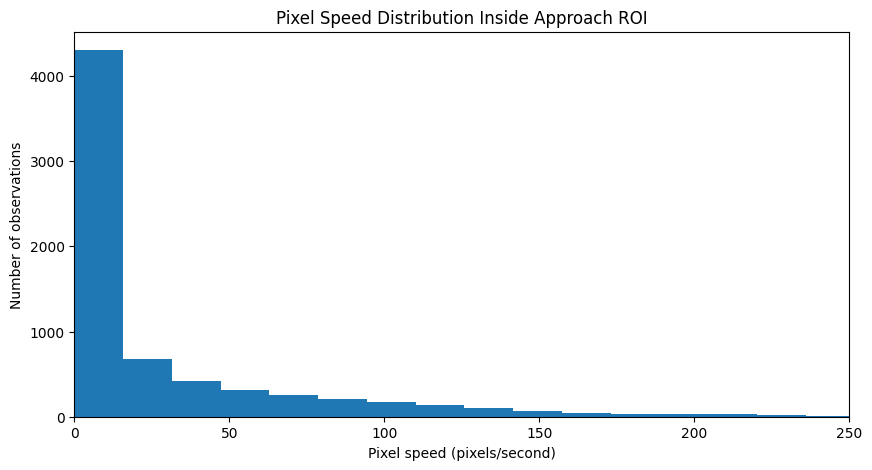

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_speed["pixel_speed"],
    bins=50
)

plt.xlabel("Pixel speed (pixels/second)")
plt.ylabel("Number of observations")
plt.title("Pixel Speed Distribution Inside Approach ROI")
plt.xlim(0, 250)

plt.show()

In [15]:
thresholds = [10, 20, 30, 40, 50]

for threshold in thresholds:
    slow_count = (df_speed["pixel_speed"] <= threshold).sum()
    percentage = (slow_count / len(df_speed)) * 100

    print(
        f"{threshold:>3} pixels/s → "
        f"{slow_count:>4} observations "
        f"({percentage:.2f}%)"
    )

 10 pixels/s → 3755 observations (54.33%)
 20 pixels/s → 4536 observations (65.63%)
 30 pixels/s → 4943 observations (71.52%)
 40 pixels/s → 5216 observations (75.47%)
 50 pixels/s → 5479 observations (79.28%)


In [16]:
FPS = 25
MIN_QUEUE_DURATION = 1.0
thresholds = [20, 30, 40, 50]

df_q = df_speed.sort_values(
    ["track_id", "frame"]
).copy()

df_q["is_slow"] = False

for threshold in thresholds:
    temp = df_q.copy()

    temp["is_slow"] = temp["pixel_speed"] <= threshold

    # Break a run when:
    # 1. the vehicle is no longer slow, or
    # 2. tracking has a large frame gap
    temp["frame_gap"] = (
        temp.groupby("track_id")["frame"].diff()
    )

    temp["run_break"] = (
        (~temp["is_slow"]) |
        (temp["frame_gap"] > 5) |
        (temp["frame_gap"].isna())
    )

    temp["run_id"] = (
        temp.groupby("track_id")["run_break"]
        .cumsum()
    )

    slow_runs = (
        temp[temp["is_slow"]]
        .groupby(["track_id", "run_id"])
        .agg(
            start_frame=("frame", "min"),
            end_frame=("frame", "max"),
            observations=("frame", "count")
        )
        .reset_index()
    )

    slow_runs["duration_seconds"] = (
        (slow_runs["end_frame"] - slow_runs["start_frame"])
        / FPS
    )

    persistent = slow_runs[
        slow_runs["duration_seconds"] >= MIN_QUEUE_DURATION
    ]

    print(
        f"{threshold:>3} pixels/s → "
        f"{len(persistent)} persistent slow runs, "
        f"{persistent['track_id'].nunique()} vehicles"
    )

 20 pixels/s → 42 persistent slow runs, 11 vehicles
 30 pixels/s → 57 persistent slow runs, 11 vehicles
 40 pixels/s → 60 persistent slow runs, 13 vehicles
 50 pixels/s → 54 persistent slow runs, 14 vehicles


In [17]:
import pandas as pd

def detect_queued_vehicles(
    df,
    speed_threshold,
    min_queue_duration,
    fps,
    max_frame_gap=5
):
    df = df.copy()
    df = df.sort_values(["track_id", "frame"]).reset_index(drop=True)

    df["frame_gap"] = df.groupby("track_id")["frame"].diff()

    df["is_slow"] = (
        df["pixel_speed"] <= speed_threshold
    )

    df["run_break"] = (
        (~df["is_slow"]) |
        (df["frame_gap"] > max_frame_gap) |
        (df["frame_gap"].isna())
    )

    df["run_id"] = (
        df.groupby("track_id")["run_break"]
        .cumsum()
    )

    slow_df = df[df["is_slow"]].copy()

    if slow_df.empty:
        return pd.DataFrame(
            columns=[
                "track_id",
                "run_id",
                "start_frame",
                "end_frame",
                "observations",
                "duration_seconds"
            ]
        )

    queue_runs = (
        slow_df
        .groupby(["track_id", "run_id"])
        .agg(
            start_frame=("frame", "min"),
            end_frame=("frame", "max"),
            observations=("frame", "count")
        )
        .reset_index()
    )

    queue_runs["duration_seconds"] = (
        (queue_runs["end_frame"] -
         queue_runs["start_frame"]) / fps
    )

    queue_runs = queue_runs[
        queue_runs["duration_seconds"] >= min_queue_duration
    ].copy()

    return queue_runs


def estimate_queue_length(df_queued):
    if df_queued.empty:
        return 0

    return int(df_queued["track_id"].nunique())

In [18]:
queued_runs = detect_queued_vehicles(
    df_speed,
    speed_threshold= 20,
    min_queue_duration=1.0,
    fps=25,
    max_frame_gap=5
)

print("Persistent queue runs:", len(queued_runs))
print("Queued vehicles:", estimate_queue_length(queued_runs))

display(queued_runs)

Persistent queue runs: 42
Queued vehicles: 11


,track_id,run_id,start_frame,end_frame,observations,duration_seconds
16,148,105,245,297,53,2.08
18,148,107,325,377,53,2.08
21,148,110,407,449,43,1.68
23,148,112,458,485,28,1.08
34,148,132,600,645,46,1.80
47,148,149,780,817,38,1.48
50,148,153,860,885,26,1.00
60,148,166,1020,1045,26,1.00
65,148,173,1100,1125,26,1.00
68,148,177,1142,1169,28,1.08


In [19]:
print("Unique track IDs:")
print(sorted(queued_runs["track_id"].unique()))

print("\nNumber of unique track IDs:")
print(queued_runs["track_id"].nunique())

Unique track IDs:
[np.int64(148), np.int64(151), np.int64(171), np.int64(174), np.int64(181), np.int64(195), np.int64(238), np.int64(274), np.int64(280), np.int64(282), np.int64(286)]

Number of unique track IDs:
11


In [20]:
queued_ids = sorted(queued_runs["track_id"].unique())

print("Queued vehicle IDs:", queued_ids)
print("Number of queued vehicles:", len(queued_ids))

Queued vehicle IDs: [np.int64(148), np.int64(151), np.int64(171), np.int64(174), np.int64(181), np.int64(195), np.int64(238), np.int64(274), np.int64(280), np.int64(282), np.int64(286)]
Number of queued vehicles: 11


In [21]:
import cv2
import matplotlib.pyplot as plt

# Pick one representative frame from each queued vehicle's
# detected queue period
sample_frames = []

for track_id in queued_ids:
    vehicle_rows = queued_runs[
        queued_runs["track_id"] == track_id
    ]

    # Take the middle of the first qualifying queue run
    row = vehicle_rows.iloc[0]

    sample_frame = int(
        (row["start_frame"] + row["end_frame"]) / 2
    )

    sample_frames.append(
        (track_id, sample_frame)
    )

print("Frames selected for visual validation:")
for track_id, frame_no in sample_frames:
    print(f"Vehicle {track_id} → frame {frame_no}")

Frames selected for visual validation:
Vehicle 148 → frame 271
Vehicle 151 → frame 257
Vehicle 171 → frame 566
Vehicle 174 → frame 472
Vehicle 181 → frame 488
Vehicle 195 → frame 646
Vehicle 238 → frame 952
Vehicle 274 → frame 978
Vehicle 280 → frame 1032
Vehicle 282 → frame 1219
Vehicle 286 → frame 1148


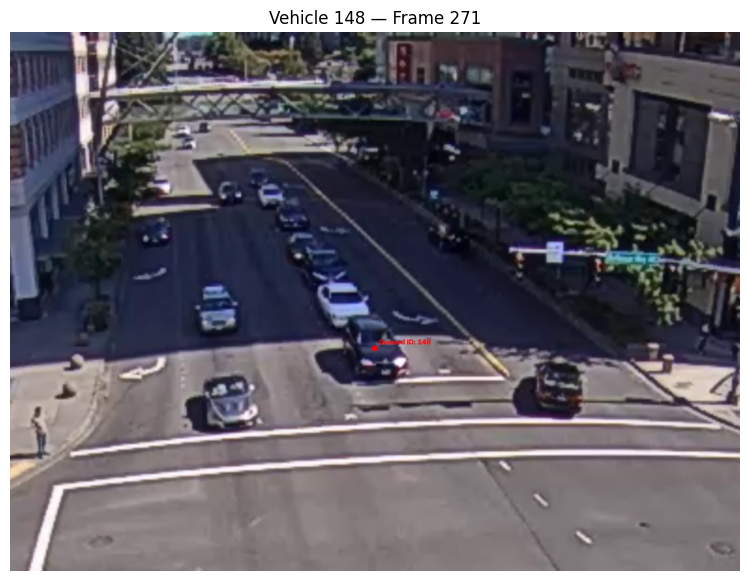

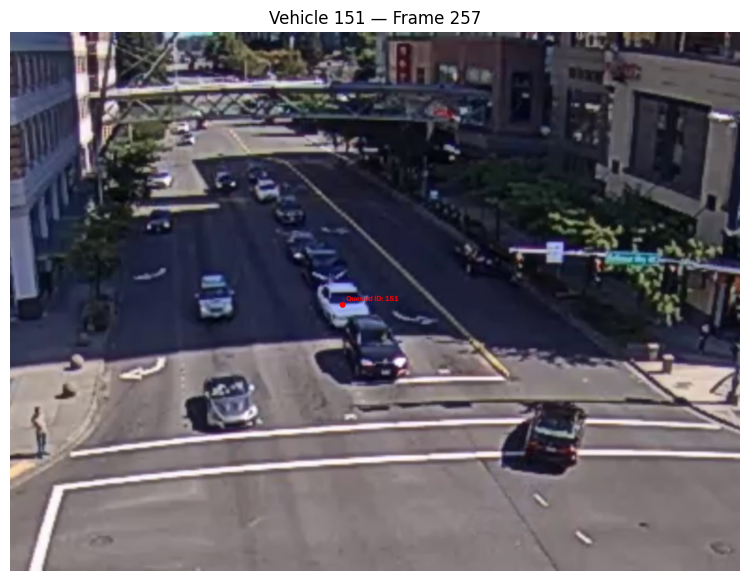

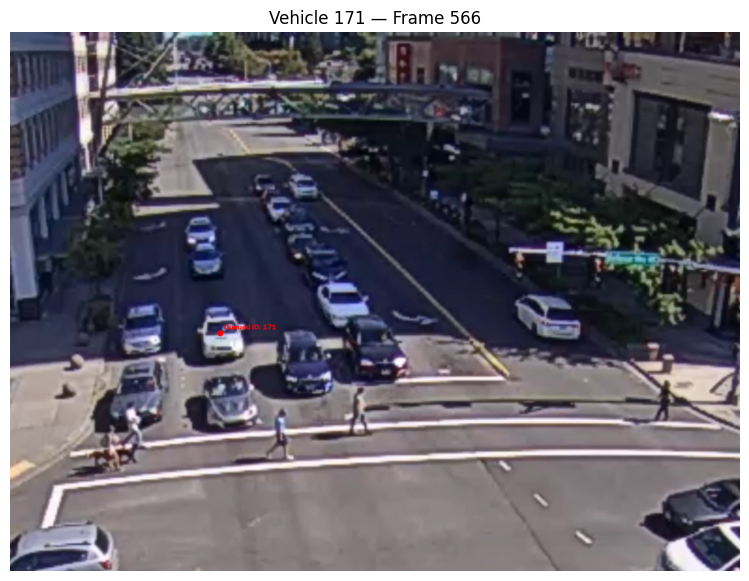

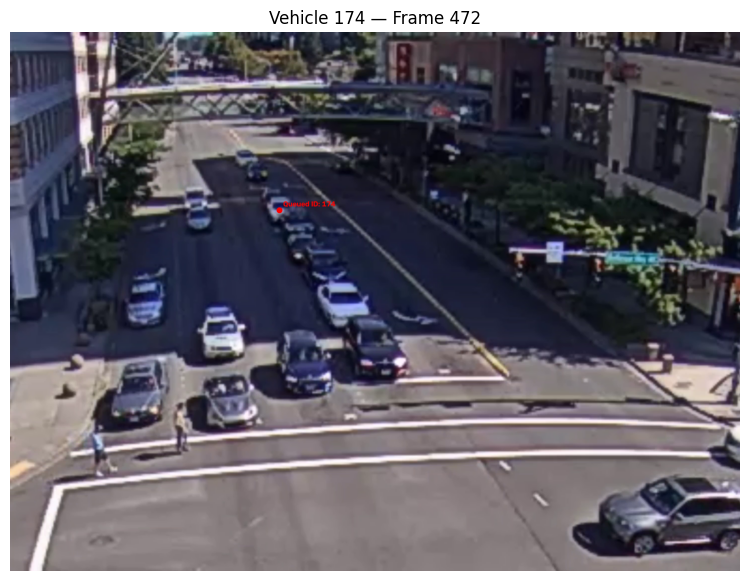

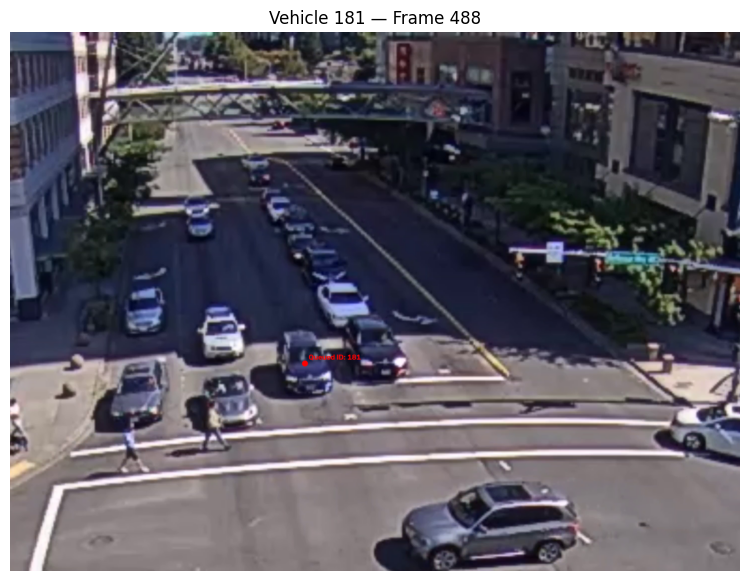

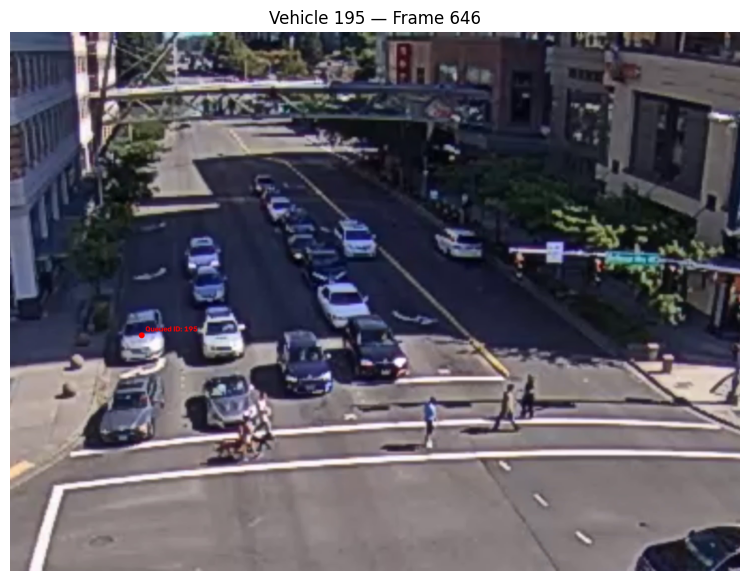

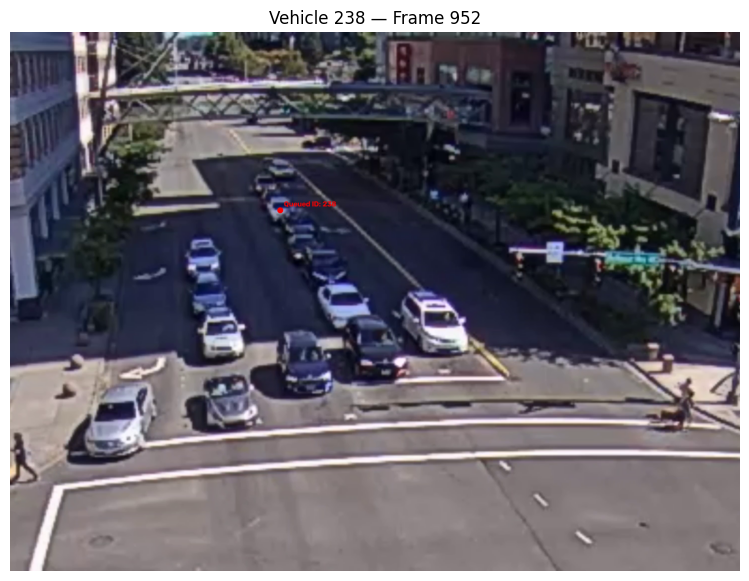

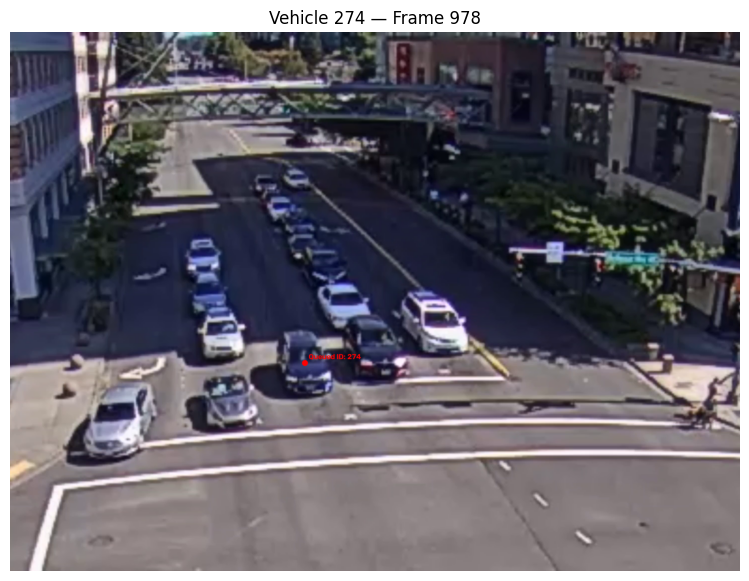

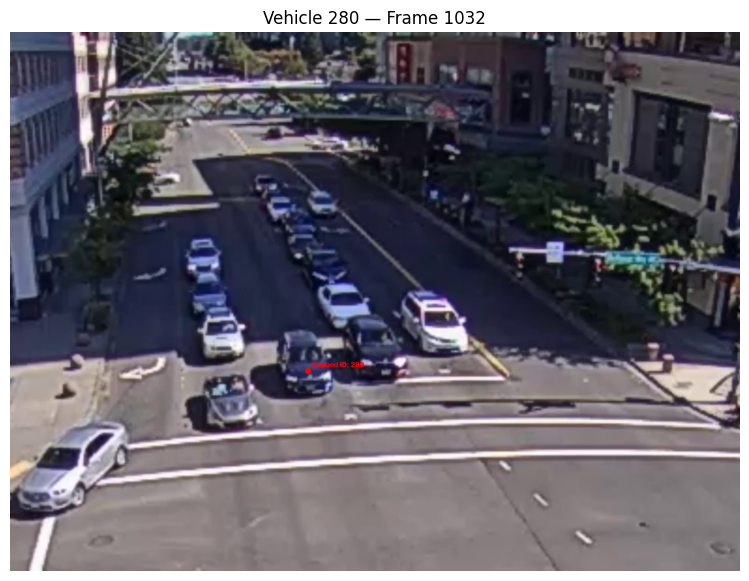

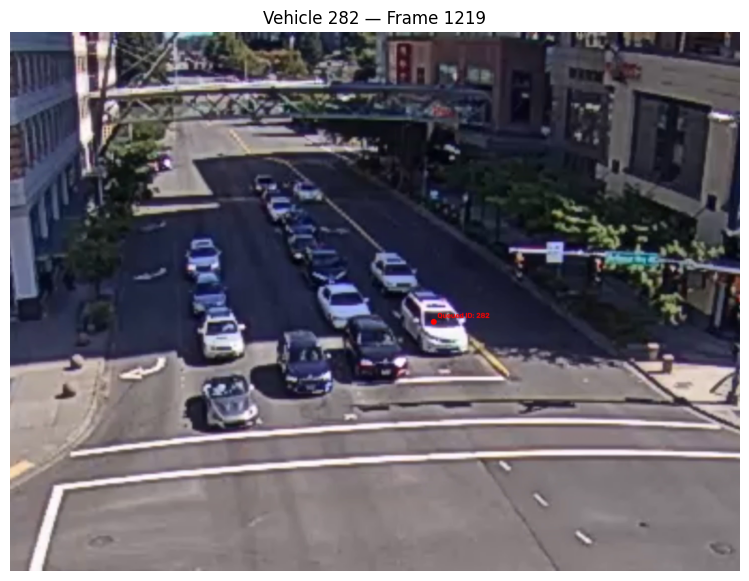

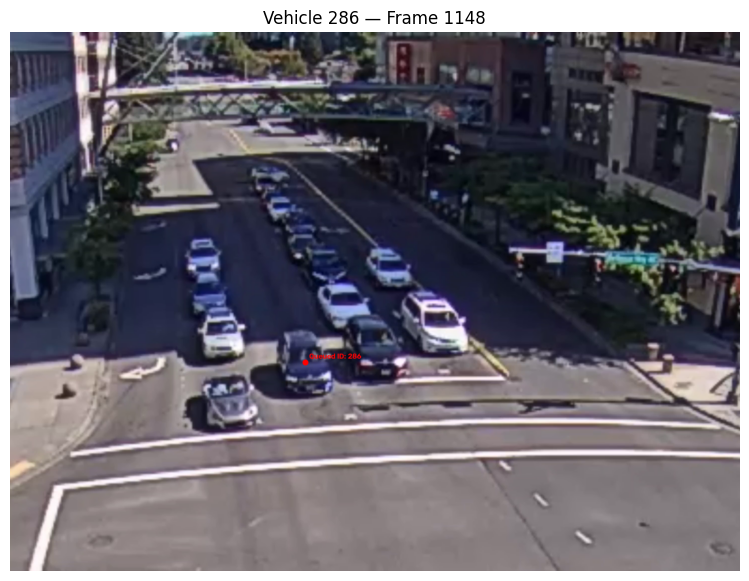

In [22]:
import cv2
import matplotlib.pyplot as plt

video_path = video_path  # use your current video path

cap = cv2.VideoCapture(video_path)

for track_id, frame_no in sample_frames:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
    ret, frame = cap.read()

    if not ret:
        print(f"Could not read frame {frame_no}")
        continue

    # Find this vehicle's position at the selected frame
    vehicle = df[
        (df["track_id"] == track_id) &
        (df["frame"] == frame_no)
    ]

    if len(vehicle) == 0:
        print(f"Vehicle {track_id} not found at frame {frame_no}")
        continue

    row = vehicle.iloc[0]

    x = int(row["center_x"])
    y = int(row["center_y"])

    # Mark the tracked vehicle center
    cv2.circle(frame, (x, y), 12, (0, 0, 255), -1)

    cv2.putText(
        frame,
        f"Queued ID: {track_id}",
        (x + 15, y - 15),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 255),
        2
    )

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 7))
    plt.imshow(frame_rgb)
    plt.title(f"Vehicle {track_id} — Frame {frame_no}")
    plt.axis("off")
    plt.show()

cap.release()

In [23]:
print("df_roi columns:")
print(df_roi.columns.tolist())

print("\ndf_speed columns:")
print(df_speed.columns.tolist())

print("\nVehicles in ROI:", df_roi["track_id"].nunique())
print("Vehicles with speed data:", df_speed["track_id"].nunique())

df_roi columns:
['frame', 'track_id', 'class', 'center_x', 'center_y', 'in_roi', 'direction']

df_speed columns:
['frame', 'track_id', 'class', 'center_x', 'center_y', 'in_roi', 'direction', 'time_seconds', 'delta_x', 'delta_y', 'pixel_displacement', 'frame_gap', 'time_delta', 'pixel_speed']

Vehicles in ROI: 53
Vehicles with speed data: 45


In [26]:
import importlib.util

queue_path = f"{repo_path}/cv/traffic/queue.py"

spec = importlib.util.spec_from_file_location("queue_module", queue_path)
queue_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(queue_module)

print("Queue module loaded successfully")

Queue module loaded successfully


In [27]:
# Basic traffic metrics for the current approach

vehicle_count = df_roi["track_id"].nunique()

class_counts = (
    df_roi
    .drop_duplicates("track_id")
    ["class"]
    .value_counts()
    .to_dict()
)

average_speed = df_speed["pixel_speed"].median()

queue_length = queue_module.estimate_queue_length(queued_runs)

print("Vehicle count:", vehicle_count)
print("Vehicle classes:", class_counts)
print("Representative average speed:", average_speed)
print("Queue length:", queue_length)

Vehicle count: 53
Vehicle classes: {'car': 43, 'truck': 10}
Representative average speed: 7.9400606106011695
Queue length: 11


In [28]:
%%writefile cv/traffic/traffic_state.py
from datetime import datetime, timezone


def build_direction_block(vehicles, cars, buses, trucks, motorcycles,
                           average_speed=None, queue_length=None,
                           camera_active=True):
    """
    Builds one direction's block matching the CV->ML contract shape.

    Any of vehicles/cars/buses/trucks/motorcycles/average_speed/queue_length
    may be None to indicate "not measured" (e.g. no camera deployed for this
    direction, or a metric not yet implemented) — distinct from 0, which
    means "measured, zero vehicles observed."

    camera_active is an extra field beyond the contract's stated minimum,
    added for clarity - confirm with the ML/Optimization side before
    relying on it being consumed.
    """
    return {
        "vehicles": int(vehicles) if vehicles is not None else None,
        "cars": int(cars) if cars is not None else None,
        "buses": int(buses) if buses is not None else None,
        "trucks": int(trucks) if trucks is not None else None,
        "motorcycles": int(motorcycles) if motorcycles is not None else None,
        "average_speed": average_speed,
        "queue_length": queue_length,
        "camera_active": camera_active
    }


def stub_direction_block():
    """
    Placeholder block for a direction with no deployed camera yet.
    All measurable fields are None, camera_active is False.
    """
    return build_direction_block(
        vehicles=None, cars=None, buses=None, trucks=None, motorcycles=None,
        average_speed=None, queue_length=None,
        camera_active=False
    )


def build_traffic_state(junction_id, north, south, east, west, timestamp=None):
    """
    Builds the CV -> ML traffic-state contract.

    Each of north/south/east/west must be a dict containing at minimum:
        vehicles, average_speed, queue_length
    (per-class counts optional). Use build_direction_block() or
    stub_direction_block() to construct these.
    """
    required_fields = {"vehicles", "average_speed", "queue_length"}

    for name, block in [("north", north), ("south", south), ("east", east), ("west", west)]:
        if block is None:
            raise ValueError(f"'{name}' direction block cannot be None")
        missing = required_fields - set(block.keys())
        if missing:
            raise ValueError(f"'{name}' direction block missing required fields: {sorted(missing)}")

    if timestamp is None:
        timestamp = datetime.now(timezone.utc).isoformat(timespec="seconds")

    return {
        "junction_id": junction_id,
        "timestamp": timestamp,
        "north": north,
        "south": south,
        "east": east,
        "west": west
    }

Writing cv/traffic/traffic_state.py


In [31]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "traffic_state",
    traffic_state_path
)

traffic_state = importlib.util.module_from_spec(spec)
spec.loader.exec_module(traffic_state)

print("traffic_state.py loaded successfully")

traffic_state.py loaded successfully


In [33]:
north_state = {
    "vehicles": 53,
    "cars": 43,
    "buses": 0,
    "trucks": 10,
    "motorcycles": 0,
    "average_speed": 7.94,
    "queue_length": 11
}

state = traffic_state.build_traffic_state(
    junction_id="J001",
    north=north_state,
    south=None,
    east=None,
    west=None
)

print(state)

ValueError: 'south' direction block cannot be None

In [34]:
print(open(traffic_state_path).read())

from datetime import datetime, timezone


def build_direction_block(vehicles, cars, buses, trucks, motorcycles,
                           average_speed=None, queue_length=None,
                           camera_active=True):
    """
    Builds one direction's block matching the CV->ML contract shape.

    Any of vehicles/cars/buses/trucks/motorcycles/average_speed/queue_length
    may be None to indicate "not measured" (e.g. no camera deployed for this
    direction, or a metric not yet implemented) — distinct from 0, which
    means "measured, zero vehicles observed."

    camera_active is an extra field beyond the contract's stated minimum,
    added for clarity - confirm with the ML/Optimization side before
    relying on it being consumed.
    """
    return {
        "vehicles": int(vehicles) if vehicles is not None else None,
        "cars": int(cars) if cars is not None else None,
        "buses": int(buses) if buses is not None else None,
        "trucks": int(trucks) if truck

In [35]:
north_state = traffic_state.build_direction_block(
    vehicles=53,
    cars=43,
    buses=0,
    trucks=10,
    motorcycles=0,
    average_speed=7.94,
    queue_length=11,
    camera_active=True
)

unobserved = traffic_state.stub_direction_block()

state = traffic_state.build_traffic_state(
    junction_id="J001",
    north=north_state,
    south=unobserved,
    east=unobserved,
    west=unobserved
)

print(state)

{'junction_id': 'J001', 'timestamp': '2026-09-20T08:28:57+00:00', 'north': {'vehicles': 53, 'cars': 43, 'buses': 0, 'trucks': 10, 'motorcycles': 0, 'average_speed': 7.94, 'queue_length': 11, 'camera_active': True}, 'south': {'vehicles': None, 'cars': None, 'buses': None, 'trucks': None, 'motorcycles': None, 'average_speed': None, 'queue_length': None, 'camera_active': False}, 'east': {'vehicles': None, 'cars': None, 'buses': None, 'trucks': None, 'motorcycles': None, 'average_speed': None, 'queue_length': None, 'camera_active': False}, 'west': {'vehicles': None, 'cars': None, 'buses': None, 'trucks': None, 'motorcycles': None, 'average_speed': None, 'queue_length': None, 'camera_active': False}}


In [36]:
import json

output_path = (
    "/content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization"
    "/cv/output/traffic_states/traffic_state_test.json"
)

with open(output_path, "w") as f:
    json.dump(state, f, indent=2)

print("Saved:", output_path)

Saved: /content/AI_Adaptive_Traffic_Analysis_and_Signal_Optimization/cv/output/traffic_states/traffic_state_test.json


In [37]:
bad_north = {
    "vehicles": 53,
    "average_speed": 7.94
    # queue_length intentionally missing
}

try:
    traffic_state.build_traffic_state(
        junction_id="J001",
        north=bad_north,
        south=unobserved,
        east=unobserved,
        west=unobserved
    )
except ValueError as e:
    print("Validation passed:", e)

Validation passed: 'north' direction block missing required fields: ['queue_length']
